In [11]:
# plotting_03 contains subject wise fatigue distribution plot for selected subjects (SNR >= 1)

In [1]:
# 1. Import Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.decomposition import PCA
from sklearn.svm import SVR

sns.set(style="white")

In [2]:
# 1A. Mount google drive with colab

from google.colab import drive
drive.mount('/content/drive')

# After mounting, verify your files are visible
import os

# Change this path to wherever your folder is in Google Drive
folder_path = '/content/drive/MyDrive/SNR_HI/'

print("Files found in your folder:")
for f in os.listdir(folder_path):
    print(f" - {f}")

Mounted at /content/drive
Files found in your folder:
 - S03HI_features_bandpower_z.csv
 - S06HI_features_bandpower_z.csv
 - S09HI_features_bandpower_z.csv
 - S11HI_features_bandpower_z.csv
 - S12HI_features_bandpower_z.csv
 - S17HI_features_bandpower_z.csv
 - S19HI_features_bandpower_z.csv
 - S20HI_features_bandpower_z.csv
 - S24HI_features_bandpower_z.csv
 - S25HI_features_bandpower_z.csv
 - S31HI_features_bandpower_z.csv
 - S36HI_features_bandpower_z.csv
 - S40HI_features_bandpower_z.csv
 - S42HI_features_bandpower_z.csv
 - S43HI_features_bandpower_z.csv


In [3]:
# 2. Setting the data path

import os

# Path to your folder in Google Drive
folder_path = '/content/drive/MyDrive/SNR_HI/'

# List all CSV files found
all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

print(f"Total CSV files found: {len(all_files)}")
print("\nFiles detected:")
for f in sorted(all_files):
    print(f"  - {f}")

Total CSV files found: 15

Files detected:
  - S03HI_features_bandpower_z.csv
  - S06HI_features_bandpower_z.csv
  - S09HI_features_bandpower_z.csv
  - S11HI_features_bandpower_z.csv
  - S12HI_features_bandpower_z.csv
  - S17HI_features_bandpower_z.csv
  - S19HI_features_bandpower_z.csv
  - S20HI_features_bandpower_z.csv
  - S24HI_features_bandpower_z.csv
  - S25HI_features_bandpower_z.csv
  - S31HI_features_bandpower_z.csv
  - S36HI_features_bandpower_z.csv
  - S40HI_features_bandpower_z.csv
  - S42HI_features_bandpower_z.csv
  - S43HI_features_bandpower_z.csv


In [4]:
# 3. Load and label all files (Only Secondary)

dfs = []
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        temp = pd.read_csv(os.path.join(folder_path, file))
        temp["label"] = 1 if "HI" in file.upper() else 0
        dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
print("Total Samples:", len(df))

Total Samples: 357


In [5]:
# 4. Feature Engineering

X_raw = df.select_dtypes(include=[np.number]).drop(["label"], axis=1, errors="ignore")

X = pd.DataFrame()
X["mean"] = X_raw.mean(axis=1)
X["std"] = X_raw.std(axis=1)
X["var"] = X_raw.var(axis=1)
X["min"] = X_raw.min(axis=1)
X["max"] = X_raw.max(axis=1)
X["range"] = X["max"] - X["min"]

X["energy"] = np.square(X_raw).mean(axis=1)
X["activity_ratio"] = (X["mean"]**2) / (X["std"] + 1e-6)
X["entropy_proxy"] = -np.log1p(np.abs(X_raw)).mean(axis=1)

In [6]:
# 5. Targets
y_class = df["label"]

# Compute y_reg BEFORE X is converted to numpy array in Cell 6
energy = np.square(X_raw).mean(axis=1)   # use X_raw instead of X
std    = X_raw.std(axis=1)

y_reg = energy / (std + 1e-6)

# Clip outliers (1st–99th percentile)
lower = np.percentile(y_reg, 1)
upper = np.percentile(y_reg, 99)
y_reg = np.clip(y_reg, lower, upper)

# Normalize to [0, 1]
y_reg = (y_reg - y_reg.min()) / (y_reg.max() - y_reg.min())

print("y_reg stats:")
print(pd.Series(y_reg).describe())

y_reg stats:
count    357.000000
mean       0.230073
std        0.178855
min        0.000000
25%        0.126374
50%        0.186626
75%        0.278576
max        1.000000
dtype: float64


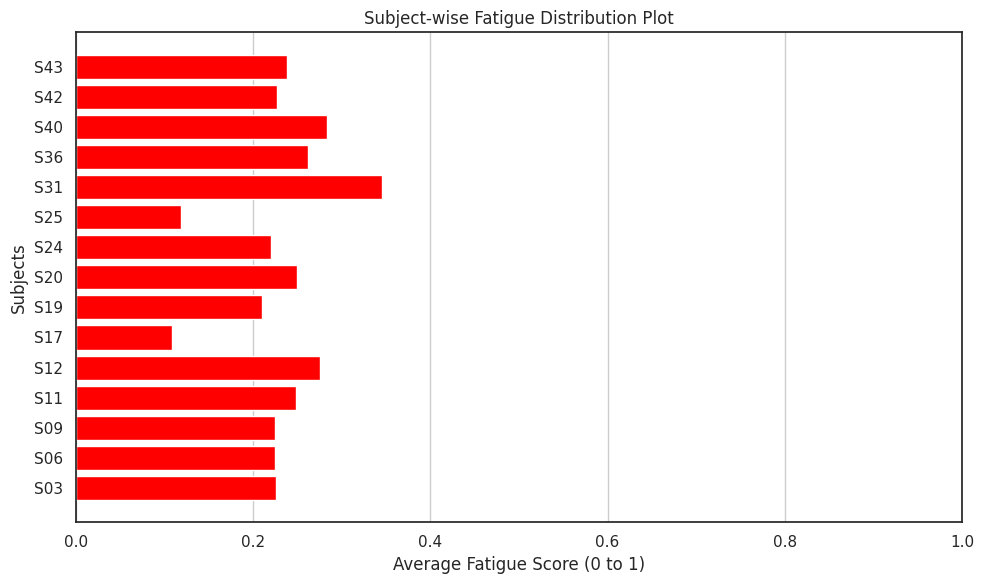

In [13]:
# Subject wise fatigue distribution plot for selected subjects (SNR >= 1)

import re

# =========================
# 1. EXTRACT SUBJECTS (MATCH EACH ROW)
# =========================
subjects = []

file_list = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

for file in file_list:
    sub_match = re.search(r"[Ss]\d{2}", file)
    subject = sub_match.group().upper() if sub_match else "UNKNOWN"

    temp = pd.read_csv(os.path.join(folder_path, file))

    # Repeat subject name for each row
    subjects.extend([subject] * len(temp))

# Add to dataframe
df["subject"] = subjects

# =========================
# 2. CREATE PLOT DATA
# =========================
plot_df = pd.DataFrame({
    "fatigue": y_reg,
    "subject": df["subject"]
})

# Compute mean fatigue per subject
subject_mean = plot_df.groupby("subject")["fatigue"].mean()

# Sort subjects properly
subject_mean = subject_mean.sort_index(key=lambda x: x.map(lambda s: int(s[1:])))

# =========================
# 3. HORIZONTAL BAR PLOT
# =========================
plt.figure(figsize=(10, 6))

plt.barh(subject_mean.index, subject_mean.values, color="red")

plt.xlabel("Average Fatigue Score (0 to 1)")
plt.ylabel("Subjects")
plt.title("Subject-wise Fatigue Distribution Plot (SNR_HI)")

plt.xlim(0, 1)
plt.grid(axis='x')

plt.tight_layout()
plt.show()